c:\Users\ruigao\AppData\Local\anaconda3\envs\pycimis_test\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 22320 (\N{CJK UNIFIED IDEOGRAPH-5730}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ruigao\AppData\Local\anaconda3\envs\pycimis_test\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 29702 (\N{CJK UNIFIED IDEOGRAPH-7406}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ruigao\AppData\Local\anaconda3\envs\pycimis_test\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 31354 (\N{CJK UNIFIED IDEOGRAPH-7A7A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ruigao\AppData\Local\anaconda3\envs\pycimis_test\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 38388 (\N{CJK UNIFIED IDEOGRAPH-95F4}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ruigao\AppData\Local\an

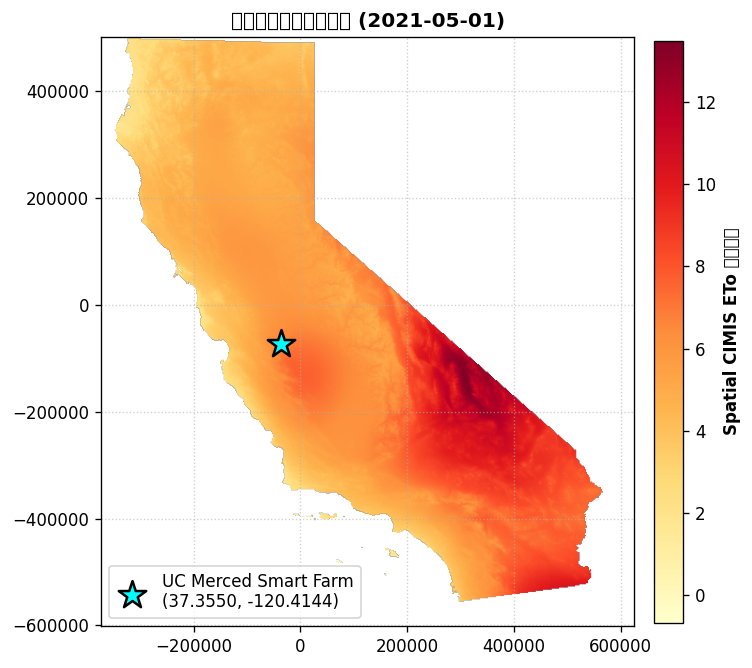


🔄 正在纵向切片提取 2-km 官方基准数据...


OSError: [WinError 1006] The volume for a file has been externally altered so that the opened file is no longer valid: 'C:\\Users\\ruigao\\Box\\1_Resources\\4_Spatial_CIMIS\\2021\\05\\02\\ETo.asc.gz'

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import pyscimis
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# =====================================================================
# 1. 路径和位置的绝对定义（紧扣你的真实 Box 路径）
# =====================================================================
CIMIS_DATA_DIR = r"C:\Users\ruigao\Box\1_Resources\4_Spatial_CIMIS"
MY_NC_DATA_DIR = r"C:\Users\ruigao\Box\1_Resources\5_ETo_30m\ETo_30m_v1"

# 假设你的 30m 历史累积数据存储在类似 ETo_30m_2023.nc 文件的立方体中
# 如果你所有的年份都在一个大 nc 里，可以直接写文件名如 "ETo_30m_v1.nc"
# 这里我用一个通用的拼接方式，请根据你文件夹下的实际 nc 文件名修改：
NC_FILE_PATH = Path(MY_NC_DATA_DIR) / "ETo_30m_2021_05.nc" 

# 设定你想要透视的目标站点（以 UC Merced Smart Farm 为例）
farm_name = "UC Merced Smart Farm"
latitude = 37.354999
longitude = -120.414366

start_date = "2021-05-01"
end_date = "2021-05-31"

# 初始化数据提取大引擎
extractor = pyscimis.LocalSpatialCimis(data_root_dir=CIMIS_DATA_DIR)

# =====================================================================
# 2. 地图展示与空间参考定位对齐验证
# =====================================================================
first_date = pd.to_datetime(start_date)
cimis_file = Path(CIMIS_DATA_DIR) / first_date.strftime('%Y') / first_date.strftime('%m') / first_date.strftime('%d') / "ETo.asc.gz"

if cimis_file.exists():
    map_data, extent, _ = extractor.load_corrected_raster(cimis_file)
    map_data_filtered = np.where(map_data < -9.0, np.nan, map_data)
    farm_proj_x, farm_proj_y = extractor.transformer.transform(longitude, latitude)

    fig, ax = plt.subplots(figsize=(7, 9), dpi=120)
    im = ax.imshow(map_data_filtered, cmap="YlOrRd", extent=extent, origin="upper")
    cbar = plt.colorbar(im, ax=ax, shrink=0.7, pad=0.03)
    cbar.set_label("Spatial CIMIS ETo 基准数值", weight='bold')
    
    # 标出红星
    ax.scatter(farm_proj_x, farm_proj_y, color="cyan", marker="*", s=300, edgecolor="black", linewidth=1.5, zorder=10,
               label=f"{farm_name}\n({latitude:.4f}, {longitude:.4f})")
    ax.set_title(f"地理空间参考定位验证 ({first_date.strftime('%Y-%m-%d')})", fontsize=12, weight='bold')
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.legend(loc="lower left")
    plt.show()
else:
    print(f"⚠️ 提示：未在 Box 中找到首日官方数据 {cimis_file}，将跳过地图验证，直接提取时序。")

# =====================================================================
# 3. 双源数据纵向切片提取与多尺度科研图表绘制
# =====================================================================
print("\n🔄 正在纵向切片提取 2-km 官方基准数据...")
df_cimis_raw = extractor.extract_time_series(latitude=latitude, longitude=longitude, start_date=start_date, end_date=end_date, variable="ETo")
df_cimis = pyscimis.convert_eto_to_metric(df_cimis_raw, column_name="ETo")

print("🔄 正在穿透 30-m NetCDF 时空立方体...")
# 自动调用专门处理 .nc 的新方法
df_my_30m = extractor.extract_from_nc_dataset(nc_path=NC_FILE_PATH, latitude=latitude, longitude=longitude, start_date=start_date, end_date=end_date, var_name="ETo")

# 将两个序列按日期强行对齐（Inner Join）
df_combined = df_cimis.join(df_my_30m, how="inner")

# 📊 绘制 2km 官方 vs 30m 你的高精度数据集时序曲线
plt.figure(figsize=(11, 4.5), dpi=120)
plt.plot(df_combined.index, df_combined["ETo_mm"], color="orange", linestyle="--", marker="x", alpha=0.75, label="Official Spatial CIMIS (2-km)")
plt.plot(df_combined.index, df_combined["ETo_30m"], color="darkblue", linestyle="-", marker="o", linewidth=2.2, label="Your High-Res Dataset (30-m)")

plt.title(f"多源参考蒸散发（ETo）时序交叉比对 - {farm_name}", fontsize=12, weight='bold', pad=12)
plt.xlabel("Date", fontsize=10)
plt.ylabel("ETo (mm/day)", fontsize=10)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc="upper right", frameon=True, facecolor="white")
plt.gcf().autofmt_xdate()
plt.show()

print("✨ 双尺度时序提取完成！前 5 行联表数据对照：")
print(df_combined[["ETo_mm", "ETo_30m"]].head())

In [1]:
# 1. 填入你的真实 CIMIS AppKey 和你希望在本地创建的数据存储总目录
# CIMIS_APP_KEY = "你的_CIMIS_APP_KEY"  
DATA_ROOT_DIR = r"C:\Users\ruigao\Documents\GitHub\pyscimis\data"  # 就在当前项目目录下创建一个新文件夹存数据

# 2. 设定你想要的研究时段、地理位置和核心变量
farm_name = "imagined_farm"
latitude = 37.354999
longitude = -120.414366
start_date = "2023-05-01"  # 让我们下载 2023 年 5 月整月的数据来测试
end_date = "2023-05-5"
target_variable = "ALL"

# 3. 初始化本地流水线工具
extractor = pyscimis.LocalSpatialCimis(data_root_dir=DATA_ROOT_DIR, app_key=api_key)

# 4. 触发一键下载功能！它会自动在本地建立 2023/05/01/ETo.asc.gz 的完美目录结构
extractor.download_spatial_data(start_date=start_date, end_date=end_date, variable=target_variable)

NameError: name 'pyscimis' is not defined

In [ ]:
import gzip
import shutil
import tempfile
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import rasterio

# 自动定位下载好的第一天的文件
first_date = pd.to_datetime(start_date)
file_path = Path(DATA_ROOT_DIR) / first_date.strftime('%Y') / first_date.strftime('%m') / first_date.strftime('%d') / f"{target_variable}.asc.gz"

# 内存解压并读取首日大地图
with tempfile.TemporaryDirectory() as tmpdir:
    target_asc = Path(tmpdir) / file_path.stem
    with gzip.open(file_path, 'rb') as f_in:
        with open(target_asc, 'wb') as f_out:
            shutil.copyfileobj(f_in, f_out)
            
    with rasterio.open(target_asc) as src:
        map_data = src.read(1)
        bounds = src.bounds
        extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]

# 转换农场的经纬度到加州标准投影
farm_proj_x, farm_proj_y = extractor.transformer.transform(longitude, latitude)
map_data_filtered = np.where(map_data < -9.0, np.nan, map_data)

# 绘图：验证地图完整度与农场空间对齐情况
fig, ax = plt.subplots(figsize=(9, 11), dpi=120)
im = ax.imshow(map_data_filtered, cmap="YlOrRd", extent=extent, origin="upper")
cbar = plt.colorbar(im, ax=ax, shrink=0.75, pad=0.03)
cbar.set_label(f"{target_variable} 空间网格数值", fontsize=11, weight='bold')

ax.scatter(farm_proj_x, farm_proj_y, color="cyan", marker="*", s=250, edgecolor="black", linewidth=1.5, zorder=5,
           label=f"Joey Pistachio Farm\n({latitude:.4f}, {longitude:.4f})")

ax.set_title(f"Spatial CIMIS 本地下载首日验证 ({first_date.strftime('%Y-%m-%d')})", fontsize=14, weight='bold', pad=15)
ax.grid(True, linestyle=":", alpha=0.6)
ax.legend(loc="lower left", frameon=True)
plt.show()

In [ ]:
# 1. 瞬时提取刚才下载的 31 天完整的空间时间序列
df_raw = extractor.extract_time_series(latitude=latitude, longitude=longitude, start_date=start_date, end_date=end_date, variable=target_variable)

# 2. 一键公制转换
df_result = pyscimis.convert_eto_to_metric(df_raw, column_name=target_variable)

# 3. 绘图
plt.figure(figsize=(10, 4), dpi=120)
plt.plot(df_result.index, df_result[f"{target_variable}_mm"], color="forestgreen", marker="o", lw=2, label="Local Extracted ETo")
plt.title(f"本地提取的每日参考蒸散发时间序列 - {farm_name.replace('_', ' ').title()}", fontsize=12)
plt.xlabel("Date")
plt.ylabel("ETo (mm/day)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.gcf().autofmt_xdate()
plt.show()

In [1]:
import pyscimis
import matplotlib.pyplot as plt

# 1. 配置文件路径（指向你存放 2004 文件夹的上一级主目录）
DATA_ROOT_DIR = r"C:\Users\YourName\Documents\GitHub\pyscimis_data"

# 2. 定义目标农场信息
farm_name = "joey_pistachio_farm"
latitude = 37.354999
longitude = -120.414366
start_date = "2004-01-01"
end_date = "2004-01-31"

# 3. 指定你想提取的本地变量（参考 __init__.py 中的命名，如 'ETo', 'Rs', 'Tx', 'Tn', 'U2'）
target_variable = "ETo"

# 初始化本地提取器
extractor = pyscimis.LocalSpatialCimis(data_root_dir=DATA_ROOT_DIR)

print(f"提取设置已就绪：\n农场: {farm_name}\n坐标: {latitude}, {longitude}\n时间段: {start_date} 至 {end_date}")

提取设置已就绪：
农场: joey_pistachio_farm
坐标: 37.354999, -120.414366
时间段: 2004-01-01 至 2004-01-31


In [2]:
print(f"正在读取本地网格并提取 [{target_variable}] 空间时间序列...")

# 从本地 2km 空间网格中抽取对应像素点的序列
df_raw = extractor.extract_time_series(
    latitude=latitude,
    longitude=longitude,
    start_date=start_date,
    end_date=end_date,
    variable=target_variable
)

# 如果你的 ETo 数据是英制(inches)，进行一键公制转换（如果是公制，直接使用 df_raw 即可）
df_result = pyscimis.convert_eto_to_metric(df_raw, column_name=target_variable)

print("\n✨ 本地数据提取并配准完成！数据前 5 行预览：")
df_result.head()

正在读取本地网格并提取 [ETo] 空间时间序列...

✨ 本地数据提取并配准完成！数据前 5 行预览：


,ETo,ETo_mm
Date,,
2004-01-01,NaN,NaN
2004-01-02,NaN,NaN
2004-01-03,NaN,NaN
2004-01-04,NaN,NaN
2004-01-05,NaN,NaN


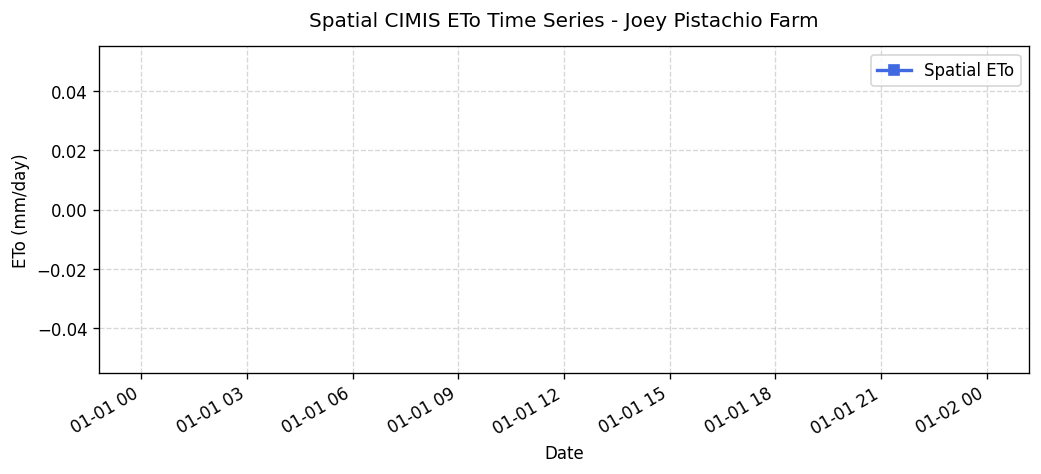

In [3]:
plt.figure(figsize=(10, 4), dpi=120)

# 如果生成了公制列则绘制公制，否则绘制原始列
plot_col = f"{target_variable}_mm" if f"{target_variable}_mm" in df_result.columns else target_variable
y_label = "ETo (mm/day)" if "mm" in plot_col else f"{target_variable} (Original Unit)"

plt.plot(df_result.index, df_result[plot_col], color="royalblue", marker="s", lw=2, label=f"Spatial {target_variable}")

plt.title(f"Spatial CIMIS {target_variable} Time Series - {farm_name.replace('_', ' ').title()}", fontsize=12, pad=12)
plt.xlabel("Date", fontsize=10)
plt.ylabel(y_label, fontsize=10)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper right")
plt.gcf().autofmt_xdate()

# 保存图表
plt.savefig(f"{farm_name}_{target_variable}_local_extract.png", bbox_inches="tight")
plt.show()

My API key is saved here: C:\Users\ruigao\Documents\CIMIS-API.txt
Is it existed? True


API key loaded.


In [22]:
import os
import matplotlib.pyplot as plt
import pyscimis

# 1. 基础配置
# CIMIS_APP_KEY = os.getenv("CIMIS_APP_KEY", "YOUR_CIMIS_APP_KEY") 
farm_name = "joey_pistachio_farm"
latitude = 37.354999
longitude = -120.414366
start_date = "2023-01-01"
end_date = "2023-01-31"

# 2. 初始化客户端
client = pyscimis.SpatialCimisClient(app_key=api_key)

# 3. 运行这行代码，它会清晰地告诉你有哪些变量可以选！
client.show_available_variables()


=== 可用的 Spatial CIMIS 核心变量名列表 ===
👉 day-asce-eto     : Reference Evapotranspiration (Standardized ASCE ETo) [inches]
👉 day-sol-rad      : Solar Radiation [Langleys/day]
👉 day-air-tmp-avg  : Average Air Temperature [°F]
👉 day-air-tmp-max  : Maximum Air Temperature [°F]
👉 day-air-tmp-min  : Minimum Air Temperature [°F]
👉 day-vap-prs-avg  : Average Vapor Pressure [mBars]
👉 day-rel-hum-max  : Maximum Relative Humidity [%]
👉 day-rel-hum-min  : Minimum Relative Humidity [%]
👉 day-dew-pnt      : Average Dew Point Temperature [°F]
👉 day-wind-spd-avg : Average Wind Speed [mph]



In [24]:
# 专注于单变量，直接传字符串，不再需要写成方括号列表了！
my_variable = "day-asce-eto" 

print(f"正在抓取 {farm_name} 的 {my_variable} 数据...")
df_raw = client.fetch_data(
    latitude=latitude, 
    longitude=longitude, 
    start_date=start_date, 
    end_date=end_date, 
    targets=my_variable
)

# 一键公制化转换
df_metric = pyscimis.convert_to_metric(df_raw)
df_metric.head()

正在抓取 joey_pistachio_farm 的 day-asce-eto 数据...


RuntimeError: API 请求失败，状态码: 400

In [ ]:
plt.figure(figsize=(10, 4), dpi=120)
plt.plot(df_metric.index, df_metric["day-asce-eto_mm"], color="forestgreen", marker="o", lw=2, label="ETo (mm/day)")

plt.title(f"Spatial CIMIS ETo - {farm_name.replace('_', ' ').title()}", fontsize=12)
plt.xlabel("Date")
plt.ylabel("ETo (mm/day)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.gcf().autofmt_xdate()
plt.show()

NameError: name 'df_metric' is not defined

<Figure size 1200x600 with 0 Axes>